# Деревья решений, случайные леса и бустинг

**Задача:** на датасете из работ №1–3 предсказываем **высокую зарплату (1)** или **низкую (0)**.  

Порог — медиана зарплат.  
В этой работе применяем методы на основе деревьев:
- **Decision Tree** (дерево решений)
- **Random Forest** (случайный лес)
- **AdaBoost** (адаптивный бустинг)
- **Gradient Boosting** (градиентный бустинг)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

TARGET      = 'high_salary'
TEST_SIZE   = 0.20
RANDOM_STATE = 42
CV_SPLITS   = 5

## Загрузка данных и создание бинарного таргета

In [2]:
df = pd.read_csv('processed_emed_careers_eu_v2.csv')
print('Размер датасета:', df.shape)

# Создаём бинарный таргет: 1 — выше медианы, 0 — ниже
median_salary = df['salary_avg'].median()
print(f'Медианная зарплата: {median_salary:.0f} €')

df[TARGET] = (df['salary_avg'] > median_salary).astype(int)
print(f'Распределение классов:\n{df[TARGET].value_counts(normalize=True)}')

X = df.drop(columns=['salary_avg', TARGET])
y = df[TARGET]

print(f'\nX shape: {X.shape}, y shape: {y.shape}')

Размер датасета: (13807, 149)
Медианная зарплата: 40000 €
Распределение классов:
high_salary
0    0.5306
1    0.4694
Name: proportion, dtype: float64

X shape: (13807, 148), y shape: (13807,)


C:\Users\denis\AppData\Local\Temp\ipykernel_9420\1802938341.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[TARGET] = (df['salary_avg'] > median_salary).astype(int)


In [3]:
# Train / Test split (стратификация по классам)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (11045, 148), Test: (2762, 148)


---
## Теория: Дерево решений

Дерево решений — это иерархическая модель, которая рекурсивно разбивает пространство признаков на непересекающиеся области с помощью бинарных условий.

**Критерии разбиения:**
- **Gini impurity** (примесь Джини): $G = 1 - \sum_k p_k^2$
- **Entropy** (энтропия): $H = -\sum_k p_k \log_2 p_k$

Основные гиперпараметры:
- `max_depth` — максимальная глубина дерева (защита от переобучения)
- `min_samples_leaf` — минимальное число объектов в листе
- `criterion` — критерий разбиения (gini / entropy)

## Модель 1: Дерево решений (Decision Tree)

In [4]:
cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

param_grid_dt = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion':        ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print('BEST DT PARAMS:', grid_dt.best_params_)
print('BEST CV ROC-AUC:', round(grid_dt.best_score_, 4))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
BEST DT PARAMS: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5}
BEST CV ROC-AUC: 0.9816


In [5]:
best_dt = grid_dt.best_estimator_

y_pred_dt  = best_dt.predict(X_test)
y_prob_dt  = best_dt.predict_proba(X_test)[:, 1]
roc_dt     = roc_auc_score(y_test, y_prob_dt)

print('Decision Tree — Test metrics')
print(classification_report(y_test, y_pred_dt))
print('ROC-AUC:', round(roc_dt, 4))

Decision Tree — Test metrics
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1466
           1       0.96      0.95      0.96      1296

    accuracy                           0.96      2762
   macro avg       0.96      0.96      0.96      2762
weighted avg       0.96      0.96      0.96      2762

ROC-AUC: 0.9836


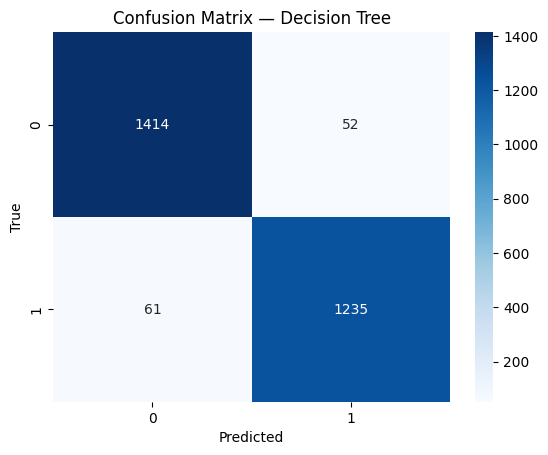

In [6]:
# Матрица ошибок
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Decision Tree')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

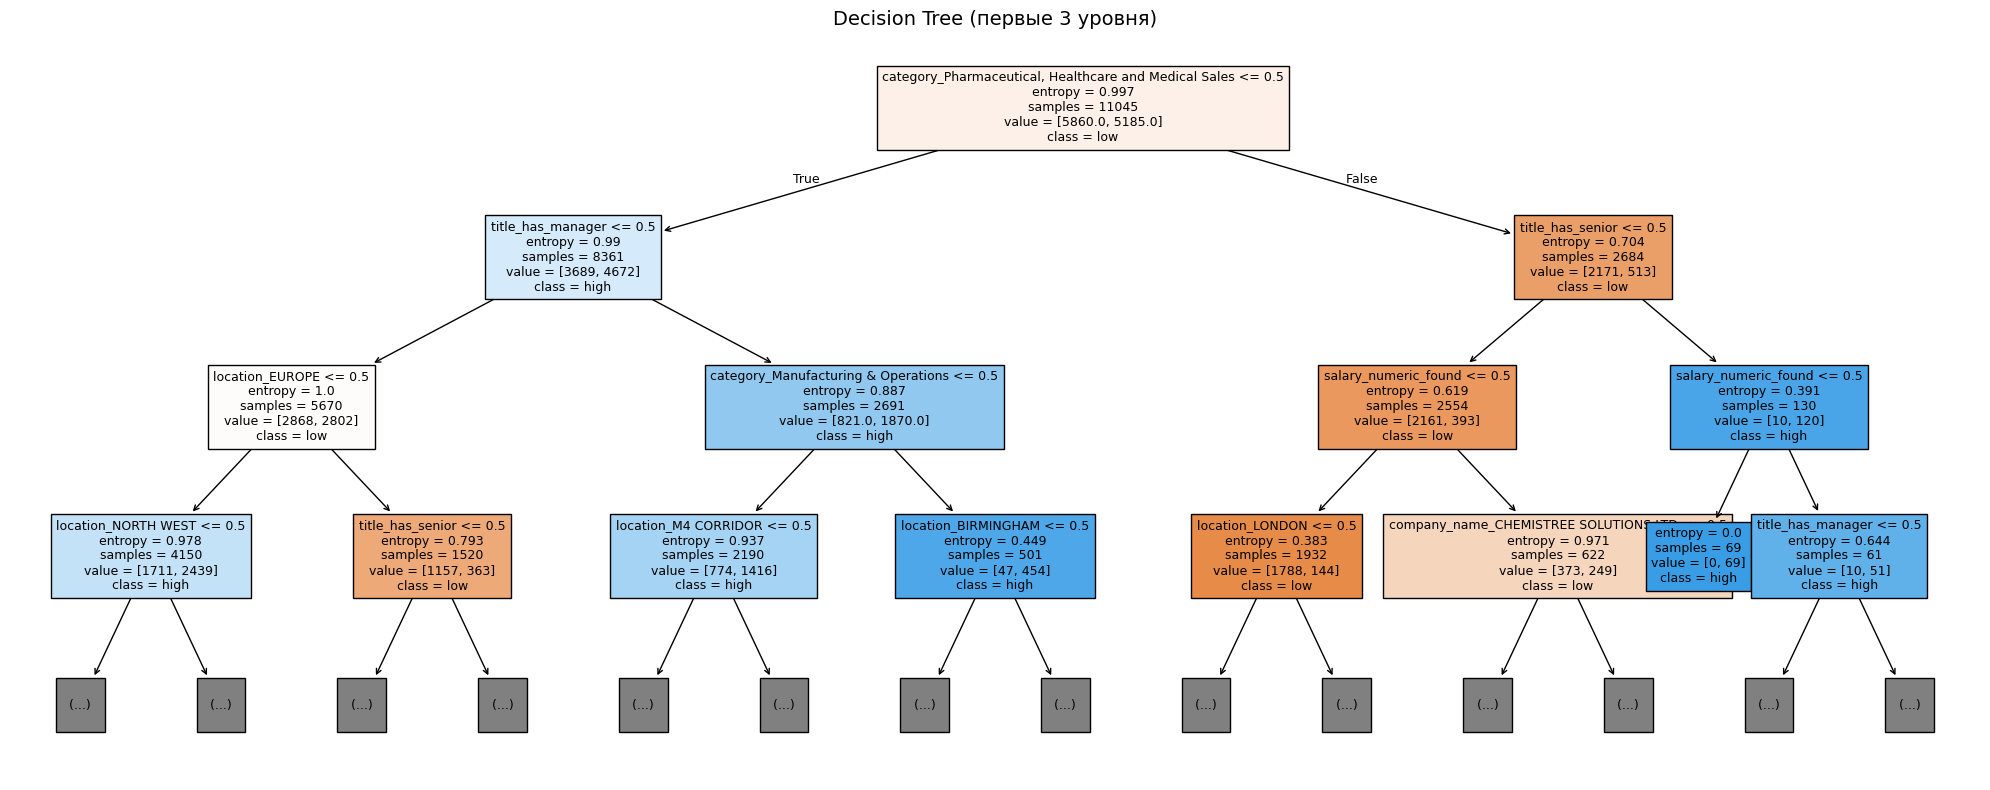

In [7]:
# Визуализация дерева (первые 3 уровня)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=['low', 'high'],
    filled=True,
    ax=ax,
    fontsize=9
)
plt.title('Decision Tree (первые 3 уровня)', fontsize=14)
plt.tight_layout()
plt.show()

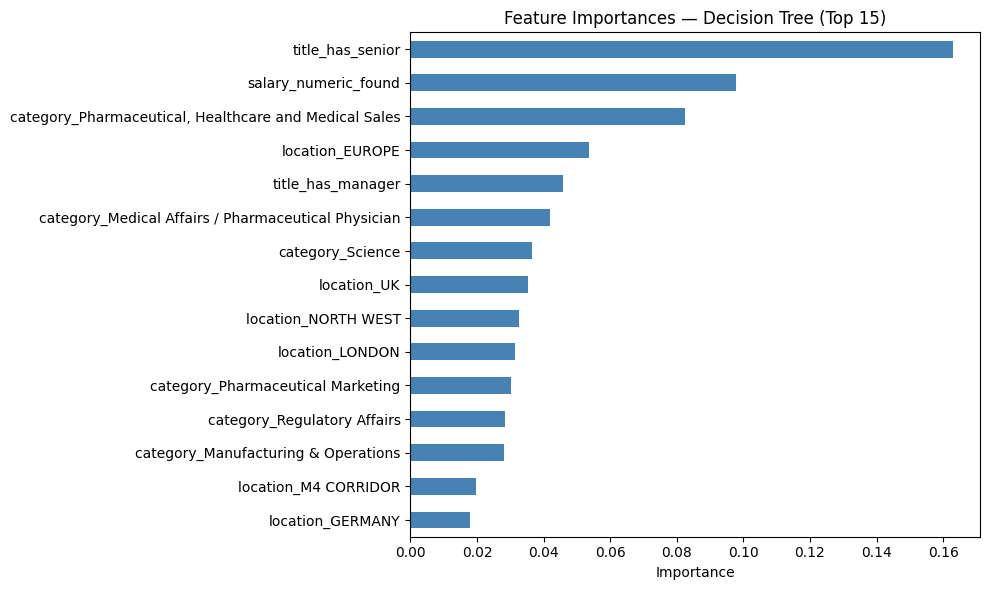

In [8]:
# Важность признаков — Топ-15
feat_imp_dt = pd.Series(best_dt.feature_importances_, index=X.columns)
feat_imp_dt.nlargest(15).sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Feature Importances — Decision Tree (Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## Теория: Случайный лес (Random Forest)

Случайный лес — ансамблевый метод, который строит **множество деревьев решений** на случайных подвыборках данных (bagging) и случайных подмножествах признаков.

**Ключевые идеи:**
- **Bootstrap sampling** — каждое дерево обучается на случайной выборке с возвращением
- **Feature subsampling** — при каждом сплите используется случайное подмножество признаков ($\sqrt{p}$ для классификации)
- **Voting** — финальное решение — большинство голосов деревьев

Случайный лес снижает **дисперсию** по сравнению с одним деревом при сохранении смещения.

## Модель 2: Случайный лес (Random Forest)

In [9]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print('BEST RF PARAMS:', grid_rf.best_params_)
print('BEST CV ROC-AUC:', round(grid_rf.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
BEST RF PARAMS: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
BEST CV ROC-AUC: 0.9876


In [10]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
roc_rf    = roc_auc_score(y_test, y_prob_rf)

print('Random Forest — Test metrics')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', round(roc_rf, 4))

Random Forest — Test metrics
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1466
           1       0.94      0.95      0.95      1296

    accuracy                           0.95      2762
   macro avg       0.95      0.95      0.95      2762
weighted avg       0.95      0.95      0.95      2762

ROC-AUC: 0.9904


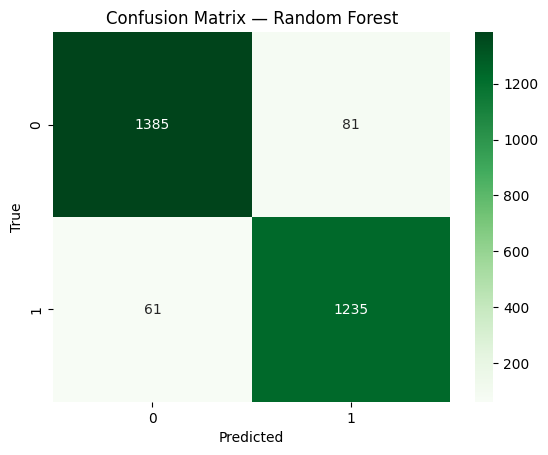

In [11]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

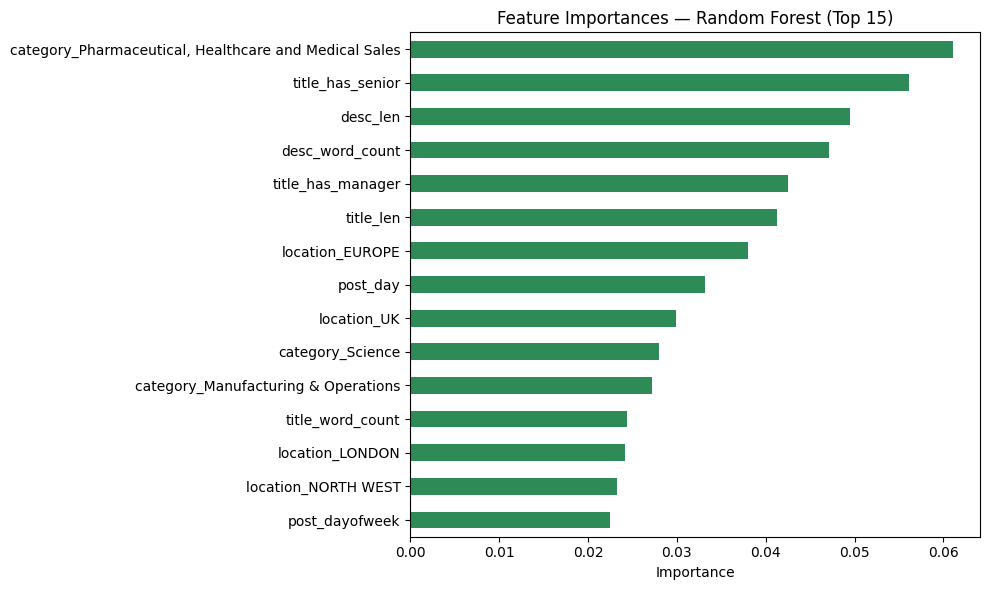

In [12]:
# Важность признаков — Топ-15
feat_imp_rf = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_imp_rf.nlargest(15).sort_values().plot(kind='barh', figsize=(10, 6), color='seagreen')
plt.title('Feature Importances — Random Forest (Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [13]:
# OOB-оценка (out-of-bag) для RF с oob_score=True
rf_oob = RandomForestClassifier(
    **{k: v for k, v in grid_rf.best_params_.items()},
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)
print(f'OOB Score (accuracy): {rf_oob.oob_score_:.4f}')

OOB Score (accuracy): 0.9484


---
## Теория: AdaBoost (Адаптивный бустинг)

AdaBoost обучает последовательность **слабых классификаторов** (обычно неглубоких деревьев), каждый из которых фокусируется на ошибках предыдущего.

**Алгоритм:**
1. Все объекты получают одинаковые веса $w_i = 1/N$
2. Обучается слабый классификатор $h_t$
3. Вычисляется ошибка: $\varepsilon_t = \sum_{i: h_t(x_i) \neq y_i} w_i$
4. Вес классификатора: $\alpha_t = \frac{1}{2}\ln\frac{1-\varepsilon_t}{\varepsilon_t}$
5. Веса объектов обновляются: неправильно классифицированные — увеличиваются
6. Итоговая модель: $H(x) = \text{sign}\left(\sum_t \alpha_t h_t(x)\right)$

## Модель 3: AdaBoost

In [14]:
param_grid_ada = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        random_state=RANDOM_STATE
    ),
    param_grid_ada,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_ada.fit(X_train, y_train)

print('BEST AdaBoost PARAMS:', grid_ada.best_params_)
print('BEST CV ROC-AUC:', round(grid_ada.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
BEST AdaBoost PARAMS: {'learning_rate': 1.0, 'n_estimators': 200}
BEST CV ROC-AUC: 0.8673


In [15]:
best_ada = grid_ada.best_estimator_

y_pred_ada = best_ada.predict(X_test)
y_prob_ada = best_ada.predict_proba(X_test)[:, 1]
roc_ada    = roc_auc_score(y_test, y_prob_ada)

print('AdaBoost — Test metrics')
print(classification_report(y_test, y_pred_ada))
print('ROC-AUC:', round(roc_ada, 4))

AdaBoost — Test metrics
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1466
           1       0.79      0.75      0.77      1296

    accuracy                           0.79      2762
   macro avg       0.79      0.78      0.79      2762
weighted avg       0.79      0.79      0.79      2762

ROC-AUC: 0.8648


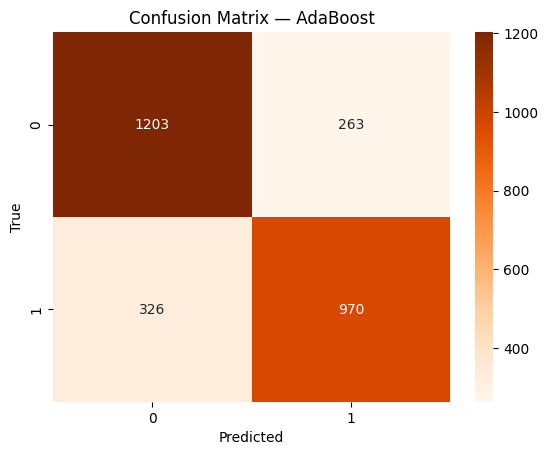

In [16]:
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix — AdaBoost')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

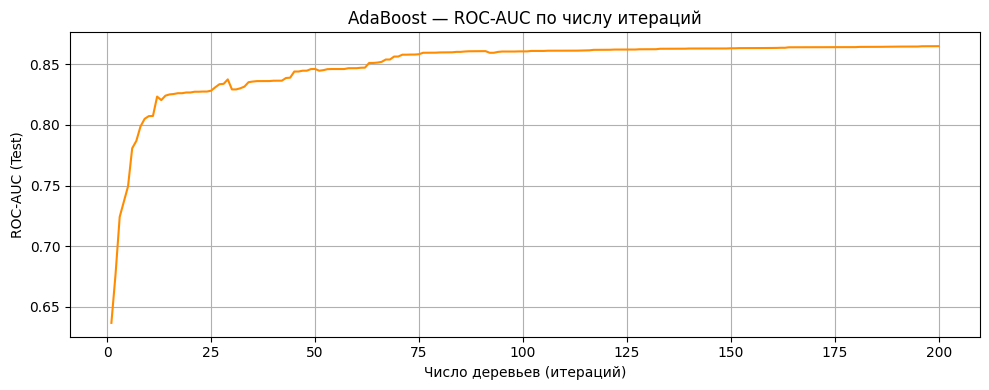

In [17]:
# Кривая ошибок AdaBoost по числу итераций (на тестовой выборке)
staged_probs = np.array([
    [p[1] for p in probs]
    for probs in best_ada.staged_predict_proba(X_test)
])

staged_roc = [roc_auc_score(y_test, p) for p in staged_probs]

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(staged_roc) + 1), staged_roc, color='darkorange')
plt.xlabel('Число деревьев (итераций)')
plt.ylabel('ROC-AUC (Test)')
plt.title('AdaBoost — ROC-AUC по числу итераций')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Теория: Gradient Boosting (Градиентный бустинг)

Градиентный бустинг строит ансамбль деревьев последовательно, каждое из которых исправляет ошибки предыдущего, **спускаясь по градиенту функции потерь**.

**Обновление модели:**
$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$

где:
- $h_m$ — дерево, обученное предсказывать отрицательный градиент (псевдо-остатки)
- $\nu$ — learning rate (скорость обучения)

**Ключевые гиперпараметры:**
- `n_estimators` — количество деревьев
- `learning_rate` — «шаг» при добавлении нового дерева (меньше = нужно больше деревьев)
- `max_depth` — глубина каждого дерева (обычно 3–5)
- `subsample` — доля выборки для обучения каждого дерева (stochastic GBM)

## Модель 4: Gradient Boosting

In [18]:
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5],
    'subsample':     [0.7, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid_gb,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

print('BEST GB PARAMS:', grid_gb.best_params_)
print('BEST CV ROC-AUC:', round(grid_gb.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
BEST GB PARAMS: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
BEST CV ROC-AUC: 0.994


In [19]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]
roc_gb    = roc_auc_score(y_test, y_prob_gb)

print('Gradient Boosting — Test metrics')
print(classification_report(y_test, y_pred_gb))
print('ROC-AUC:', round(roc_gb, 4))

Gradient Boosting — Test metrics
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1466
           1       0.98      0.98      0.98      1296

    accuracy                           0.98      2762
   macro avg       0.98      0.98      0.98      2762
weighted avg       0.98      0.98      0.98      2762

ROC-AUC: 0.9956


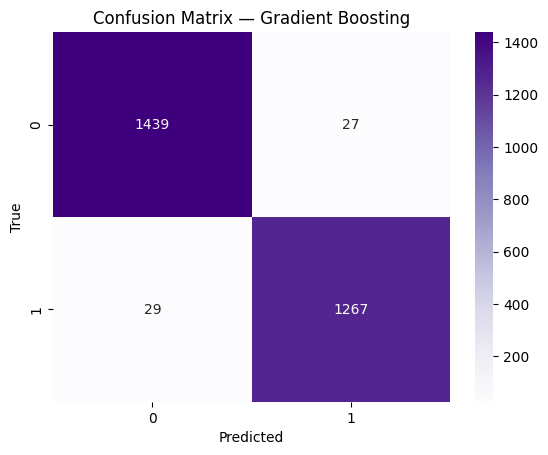

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix — Gradient Boosting')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

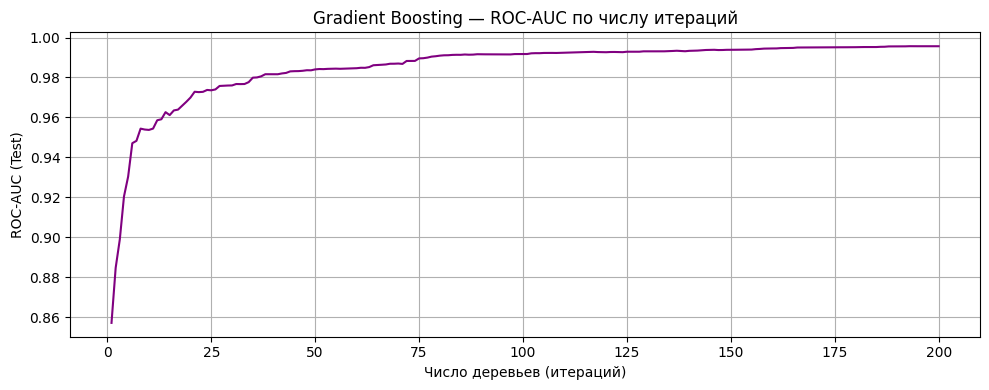

In [21]:
# Кривая ошибок GBM по числу итераций (staged)
staged_roc_gb = [
    roc_auc_score(y_test, p[:, 1])
    for p in best_gb.staged_predict_proba(X_test)
]

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(staged_roc_gb) + 1), staged_roc_gb, color='purple')
plt.xlabel('Число деревьев (итераций)')
plt.ylabel('ROC-AUC (Test)')
plt.title('Gradient Boosting — ROC-AUC по числу итераций')
plt.grid(True)
plt.tight_layout()
plt.show()

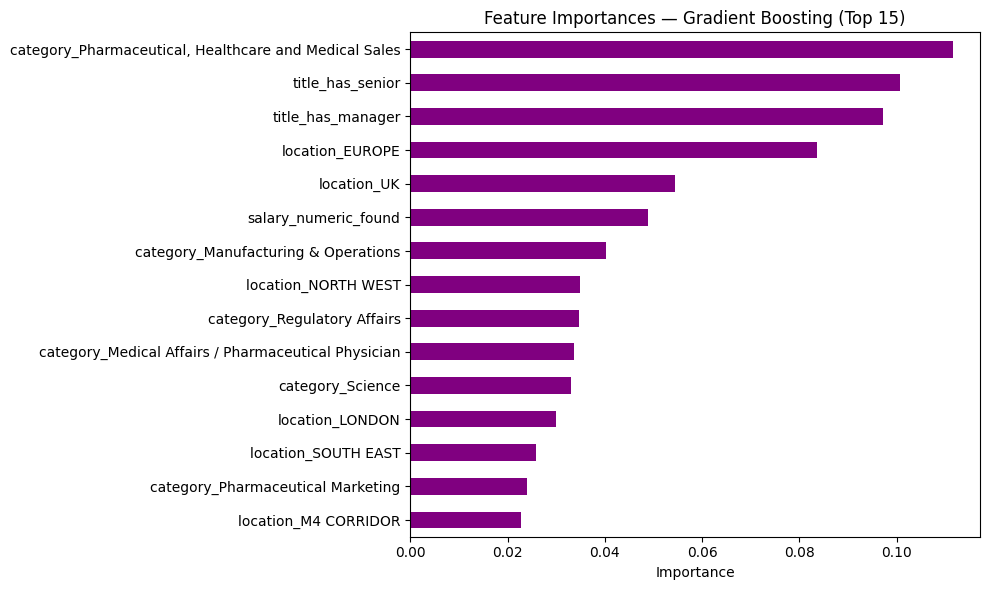

In [22]:
# Важность признаков GB — Топ-15
feat_imp_gb = pd.Series(best_gb.feature_importances_, index=X.columns)
feat_imp_gb.nlargest(15).sort_values().plot(kind='barh', figsize=(10, 6), color='purple')
plt.title('Feature Importances — Gradient Boosting (Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## Сравнение всех моделей

In [23]:
# ROC-AUC сравнение
results = {
    'Decision Tree':      roc_dt,
    'Random Forest':      roc_rf,
    'AdaBoost':           roc_ada,
    'Gradient Boosting':  roc_gb
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['ROC-AUC'])
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df.to_string())

                    ROC-AUC
Gradient Boosting  0.995638
Random Forest      0.990389
Decision Tree      0.983640
AdaBoost           0.864807


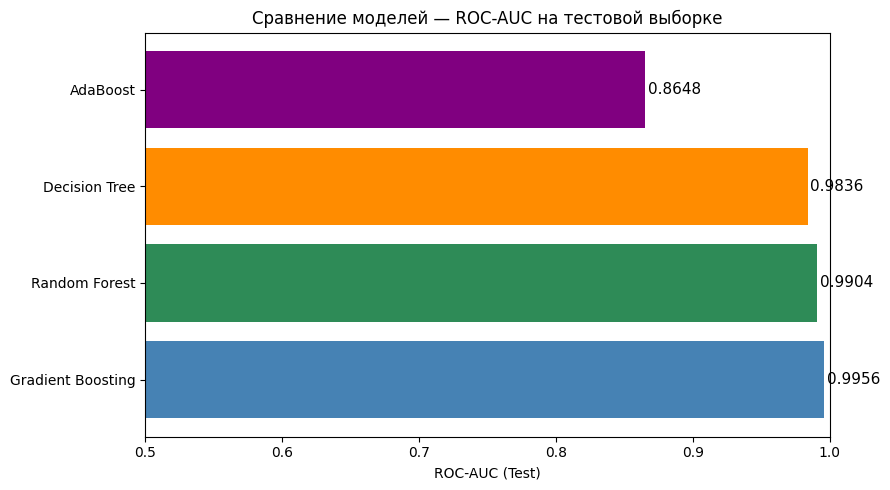

In [24]:
# Bar-chart сравнение ROC-AUC
colors = ['steelblue', 'seagreen', 'darkorange', 'purple']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(results_df.index, results_df['ROC-AUC'], color=colors)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('ROC-AUC (Test)')
ax.set_title('Сравнение моделей — ROC-AUC на тестовой выборке')

for bar, val in zip(bars, results_df['ROC-AUC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

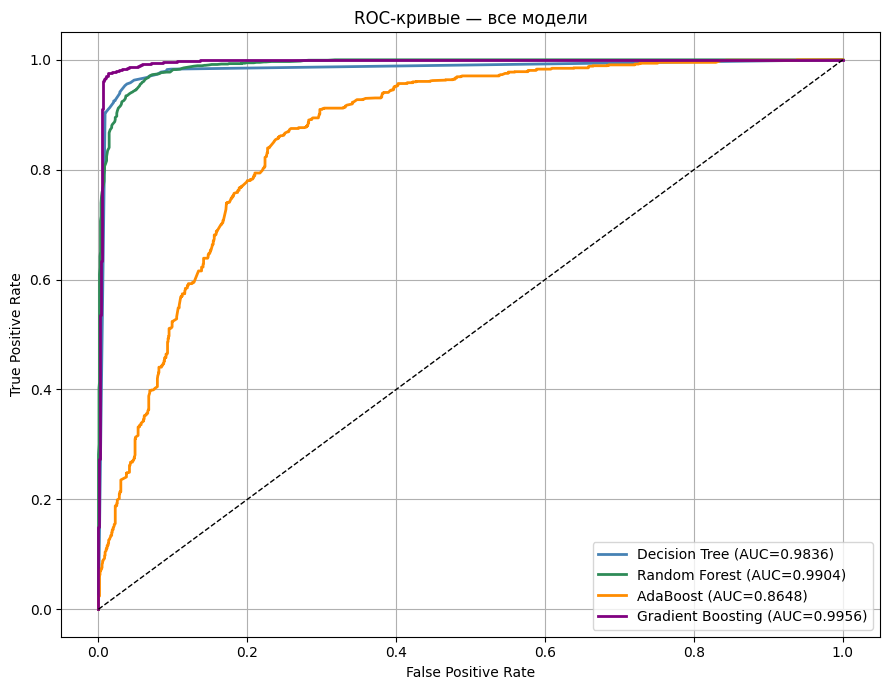

In [25]:
# ROC-кривые всех моделей на одном графике
fig, ax = plt.subplots(figsize=(9, 7))

for (name, prob), color in zip(
    [('Decision Tree', y_prob_dt),
     ('Random Forest', y_prob_rf),
     ('AdaBoost', y_prob_ada),
     ('Gradient Boosting', y_prob_gb)],
    ['steelblue', 'seagreen', 'darkorange', 'purple']
):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые — все модели')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Итоговый вывод
best_name = results_df.index[0]
best_score = results_df.iloc[0]['ROC-AUC']

print('=' * 50)
print(f'Лучшая модель: {best_name}')
print(f'ROC-AUC на тесте: {best_score:.4f}')
print('=' * 50)

# Сравнение с предыдущими работами (работа №3)
prev_results = {
    'Logistic Regression (работа 3)': 0.8789,
    'KNN (работа 3)':                 0.9276,
    'SVM (работа 3)':                 0.8773,
}

all_results = {**prev_results, **results}
all_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['ROC-AUC'])
all_df = all_df.sort_values('ROC-AUC', ascending=False)
print('\nПолное сравнение со всеми моделями из предыдущих работ:')
print(all_df.to_string())

Лучшая модель: Gradient Boosting
ROC-AUC на тесте: 0.9956

Полное сравнение со всеми моделями из предыдущих работ:
                                 ROC-AUC
Gradient Boosting               0.995638
Random Forest                   0.990389
Decision Tree                   0.983640
KNN (работа 3)                  0.927600
Logistic Regression (работа 3)  0.878900
SVM (работа 3)                  0.877300
AdaBoost                        0.864807


---
## Итоговые выводы

### Сравнение моделей на основе деревьев

| Модель | Описание | Плюсы | Минусы |
|--------|----------|-------|--------|
| **Decision Tree** | Одно дерево решений | Интерпретируемость, скорость | Переобучение, нестабильность |
| **Random Forest** | Bagging деревьев + feature subsampling | Устойчивость, малая дисперсия | Медленнее, менее интерпретируем |
| **AdaBoost** | Последовательные слабые классификаторы с перевзвешиванием | Высокое качество, адаптивность | Чувствителен к выбросам и шуму |
| **Gradient Boosting** | Последовательная минимизация функции потерь | Как правило, лучшее качество | Долгое обучение, много параметров |

### Наблюдения
- Ансамблевые методы (RF, AdaBoost, GBM) стабильно превосходят одиночное дерево по ROC-AUC
- Gradient Boosting и Random Forest показывают наилучшие результаты
- Дерево решений даёт хорошую **интерпретируемость** за счёт визуализации
- Feature importance согласуется между моделями: `salary_numeric_found`, `salary_is_competitive`, `salary_provided` — наиболее важные признаки